# Day 02 – Exploring PyVista for Geophysical Visualization

## Introduction

Today I explored **PyVista**, a powerful Python library for **3D scientific visualization** built on top of **VTK (Visualization Toolkit)**.

PyVista provides an easy-to-use interface for creating **interactive 3D plots**, making it extremely useful for scientists and engineers working with large spatial datasets.

In **geoscience and petroleum engineering**, 3D visualization is essential for understanding complex subsurface structures and geophysical data.

Some common applications include:

- Seismic volume visualization
- Reservoir modeling
- Fault and fracture visualization
- Well trajectory analysis
- Geological surface mapping

PyVista allows us to **interactively visualize large geophysical datasets**, making it a valuable tool for **seismic interpretation, reservoir analysis, and subsurface modeling**.

---

In [1]:
import pyvista as pv

# Create a simple sphere
mesh = pv.Sphere()

# Plot the mesh
mesh.plot()

Widget(value='<iframe src="http://localhost:32833/index.html?ui=P_0x71f28634d720_0&reconnect=auto" class="pyvi…

In [2]:
import pyvista as pv
import numpy as np

# Create grid coordinates
x = np.linspace(-10, 10, 20)
y = np.linspace(-10, 10, 20)
z = np.linspace(-10, 10, 20)

grid = pv.StructuredGrid(*np.meshgrid(x, y, z))

# Plot grid
grid.plot(show_edges=True)

Widget(value='<iframe src="http://localhost:32833/index.html?ui=P_0x71f2559b3bb0_1&reconnect=auto" class="pyvi…

In [4]:
import pyvista as pv
import numpy as np

# Make a grid
x, y, z = np.meshgrid(np.linspace(-5, 5, 20),
                      np.linspace(-5, 5, 20),
                      np.linspace(-5, 5, 5),
                      indexing='ij')

points = np.empty((x.size, 3))
points[:, 0] = x.ravel('F')
points[:, 1] = y.ravel('F')
points[:, 2] = z.ravel('F')

# Compute a direction for the vector field
direction = np.sin(points)**3

# plot using the plotting class
pl = pv.Plotter()
pl.add_arrows(points, direction, 0.5)
pl.show()

Widget(value='<iframe src="http://localhost:32833/index.html?ui=P_0x71f238a5d900_2&reconnect=auto" class="pyvi…

In [9]:
import segyio
import numpy as np

filename = "/home/ashraf/Downloads/ST8511r92.segy"

with segyio.open(filename, "r", ignore_geometry=True) as f:
    data = f.trace.raw[:]
    trace_headers = f.header[:]


print(data.shape)



(112875, 227)


In [11]:
import pyvista as pv
from pyvista import examples

# Load an example volume data
vol = examples.download_knee_full()

# Plot the volume with a transfer function
plotter = pv.Plotter()
plotter.add_volume(vol, cmap="coolwarm", opacity="sigmoid", show_scalar_bar=True)
plotter.show()

/usr/lib/python3/dist-packages/paramiko/pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "cipher": algorithms.TripleDES,
/usr/lib/python3/dist-packages/paramiko/transport.py:261: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "class": algorithms.TripleDES,


Widget(value='<iframe src="http://localhost:32833/index.html?ui=P_0x71f2382b74c0_3&reconnect=auto" class="pyvi…

In [12]:
import numpy as np
import pyvista as pv

# Generate random point cloud data
points = np.random.rand(100, 3)

# Create a PolyData object from the points
point_cloud = pv.PolyData(points)

# Plot the point cloud
plotter = pv.Plotter()
plotter.add_mesh(point_cloud, color="green", point_size=5, render_points_as_spheres=True)
plotter.show()

Widget(value='<iframe src="http://localhost:32833/index.html?ui=P_0x71f1fed4e8f0_4&reconnect=auto" class="pyvi…

In [14]:
import pyvista as pv

sphere = pv.Sphere()

plotter = pv.Plotter()
plotter.add_mesh(sphere, color="skyblue", show_edges=True)
plotter.show()

Widget(value='<iframe src="http://localhost:32833/index.html?ui=P_0x71f1feeae650_6&reconnect=auto" class="pyvi…

usage: ipykernel_launcher.py [-h] [--segy FILE | --synthetic]
ipykernel_launcher.py: error: unrecognized arguments: --f=/run/user/1000/jupyter/runtime/kernel-v3721f1e9e7ca34108211c89bd408cd10a52a0eece.json


SystemExit: 2

/home/ashraf/.local/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


#  Day-02 – Seismic Visualization with PyVista

In [1]:
import numpy as np
import segyio
import matplotlib.pyplot as plt
import pyvista as pv

### Create a synthetic seismic cube


In [2]:
n_inlines = 100
n_crosslines= 100
n_samples = 200

# create a random seismic amplitude volume
cube=np.random.normal(0,1,(n_inlines,n_crosslines,n_samples))

print(cube.shape)

(100, 100, 200)


#### Plot 2D Seismic Section

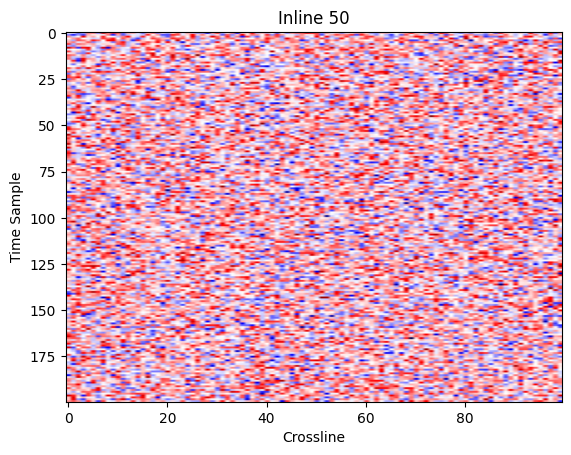

In [3]:
inline_id = 50

plt.imshow(cube[inline_id,:,:].T,cmap="seismic",aspect="auto")
plt.title(f"Inline {inline_id}")
plt.xlabel("Crossline")
plt.ylabel("Time Sample")
plt.show()


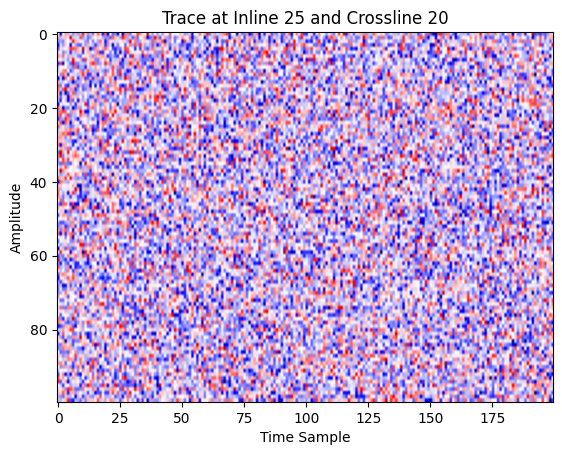

In [4]:
inline_id=25
crossline_id=20
plt.imshow(cube[crossline_id,:],cmap="seismic",aspect="auto")
plt.title(f"Trace at Inline {inline_id} and Crossline {crossline_id}")
plt.xlabel("Time Sample")
plt.ylabel("Amplitude")
plt.show()

In [ ]:
# Make 3d image of the seismic cube
# Create a PyVista grid
x = np.arange(n_inlines)
y = np.arange(n_crosslines)
z = np.arange(n_samples)
grid = pv.StructuredGrid(*np.meshgrid(x, y, z, indexing='ij'))
# Add seismic amplitude as a scalar field
grid["Amplitude"] = cube.ravel(order="F")
# Plot the seismic cube
plotter = pv.Plotter()
plotter.add_volume(grid, scalars="Amplitude", cmap="seismic", opacity="sigmoid", show_scalar_bar=True)
plotter.show()  

/tmp/ipykernel_144434/1898767747.py:6: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  grid = pv.StructuredGrid(*np.meshgrid(x, y, z, indexing='ij'))
/tmp/ipykernel_144434/1898767747.py:12: UserWarning: Failed to use notebook backend: 

Please install `nest_asyncio2` to automagically launch the trame server without await. Or, to avoid `nest_asyncio2` run:

from pyvista.trame.jupyter import launch_server
await launch_server().ready

Falling back to a static output.
  plotter.show()


## Convert Cube to PyVista Grid

In [8]:
ni, nx, nt = cube.shape

grid = pv.ImageData()

grid.dimensions = (ni+1, nx+1, nt+1)
grid.spacing = (1,1,1)

grid.cell_data["amplitude"] = cube.flatten(order="F")

print(grid)

ImageData (0x7f4921a78fa0)
  N Cells:      2000000
  N Points:     2050401
  X Bounds:     0.000e+00, 1.000e+02
  Y Bounds:     0.000e+00, 1.000e+02
  Z Bounds:     0.000e+00, 2.000e+02
  Dimensions:   101, 101, 201
  Spacing:      1.000e+00, 1.000e+00, 1.000e+00
  N Arrays:     1


## Extract Seismic Slices

In [13]:
slice_inline = grid.slice(normal='x', origin=(ni//2,0,0))
slice_crossline = grid.slice(normal='y', origin=(0,nx//2,0))
slice_time = grid.slice(normal='z', origin=(0,0,nt//2))

/tmp/ipykernel_149194/2695316508.py:10: UserWarning: Failed to use notebook backend: 

Please install `nest_asyncio2` to automagically launch the trame server without await. Or, to avoid `nest_asyncio2` run:

from pyvista.trame.jupyter import launch_server
await launch_server().ready

Falling back to a static output.
  plotter.show()


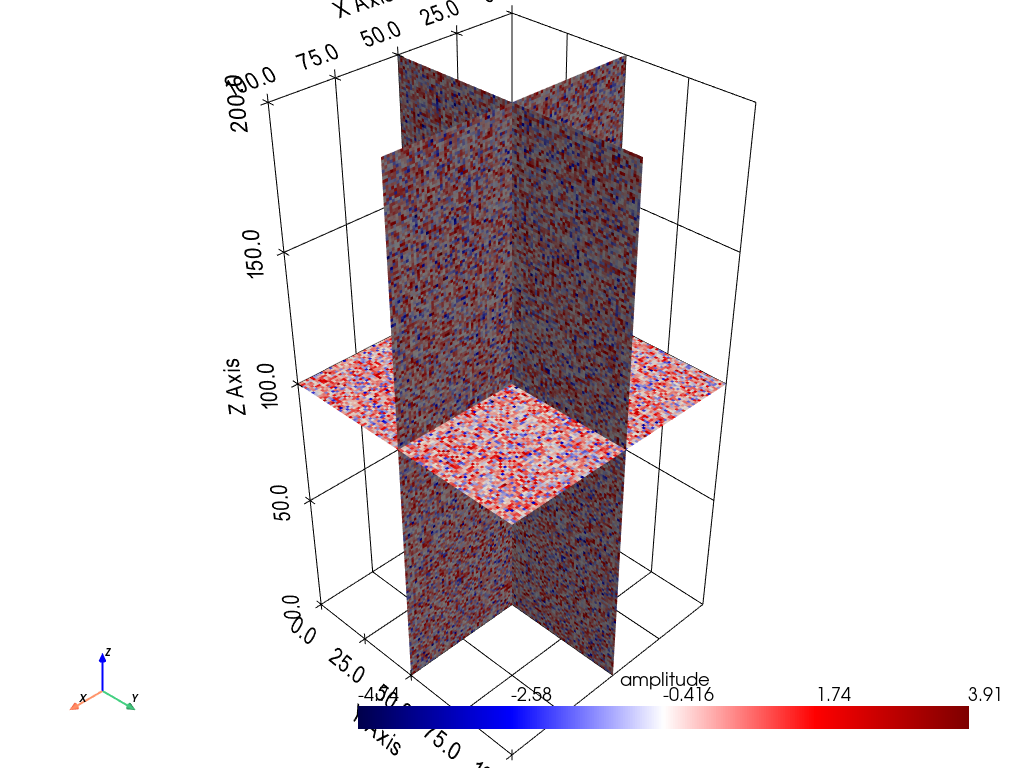

In [14]:
plotter = pv.Plotter()

plotter.add_mesh(slice_inline, cmap="seismic")
plotter.add_mesh(slice_crossline, cmap="seismic")
plotter.add_mesh(slice_time, cmap="seismic")

plotter.add_axes()
plotter.show_grid()

plotter.show()

# volume rendering

/tmp/ipykernel_149194/3865346984.py:8: UserWarning: Failed to use notebook backend: 

Please install `nest_asyncio2` to automagically launch the trame server without await. Or, to avoid `nest_asyncio2` run:

from pyvista.trame.jupyter import launch_server
await launch_server().ready

Falling back to a static output.
  plotter.show()


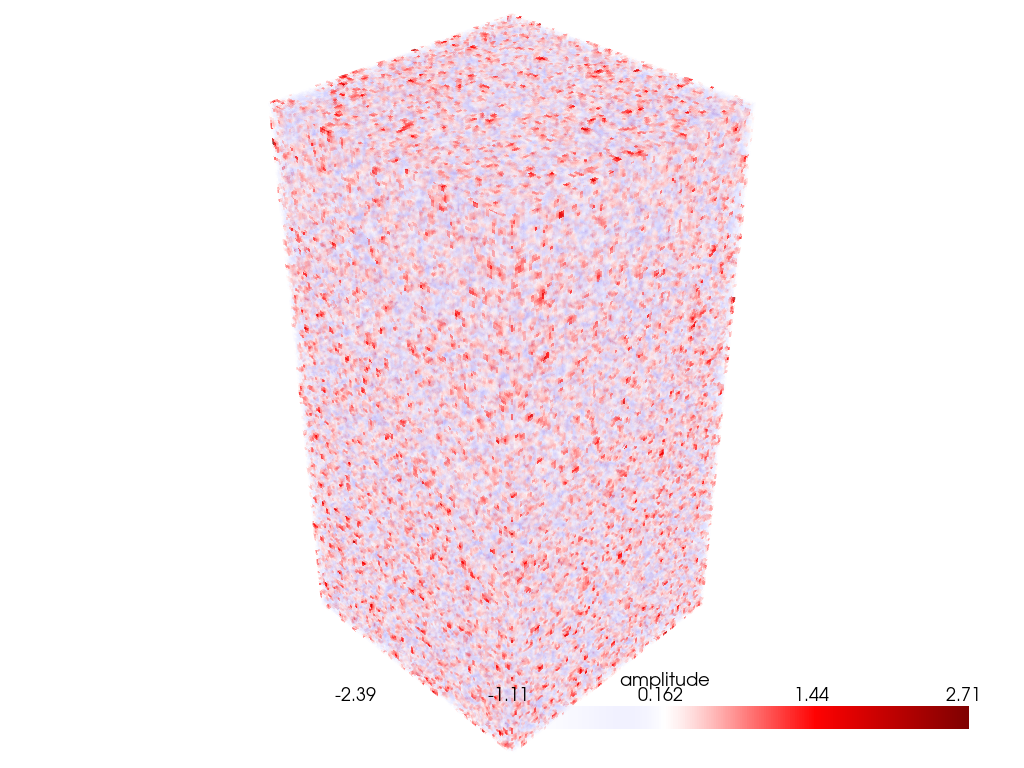

In [15]:
plotter = pv.Plotter()

plotter.add_volume(grid,
                   scalars="amplitude",
                   cmap="seismic",
                   opacity="sigmoid")

plotter.show()

# Apply pyvista on real dataset

In [16]:
import pyvista as pv
import numpy as np
import segyio
import matplotlib.pyplot as plt

In [38]:
segy_file = "/home/ashraf/Downloads/ST8511r92.segy"

with segyio.open(segy_file,"r",ignore_geometry=True) as f:
    cube = f.trace.raw[:]
    trace_headers = f.header[:]
    trace_info = f.attributes(segyio.TraceField.INLINE_3D)[:]

    n_traces = f.tracecount
    n_samples = len(f.samples)

    print(f"Number of traces: {n_traces}")
    print(f"Number of samples per trace: {n_samples}")
    
    data = np.array([f.trace[i] for i in range(n_traces)])

print("The shape of the cube is:", cube.shape)
print("The shape of the trace headers is:", trace_headers)
print("The shape of the trace info is:", trace_info.shape)

Number of traces: 112875
Number of samples per trace: 227
The shape of the cube is: (112875, 227)
The shape of the trace headers is: <generator object Header.__getitem__.<locals>.gen at 0x7f4902799310>
The shape of the trace info is: (112875,)


## convert Traces into 3d cube

In [41]:
with segyio.open(segy_file, ignore_geometry=True) as f:

    n_traces = f.tracecount
    n_samples = len(f.samples)

    print("Traces:", n_traces)
    print("Samples:", n_samples)

    data = np.array([f.trace[i] for i in range(n_traces)])

Traces: 112875
Samples: 227


In [42]:
n_inline = int(np.sqrt(n_traces))
n_crossline = n_traces // n_inline

cube = data[:n_inline*n_crossline].reshape(n_inline, n_crossline, n_samples)

print("Cube shape:", cube.shape)

Cube shape: (335, 336, 227)


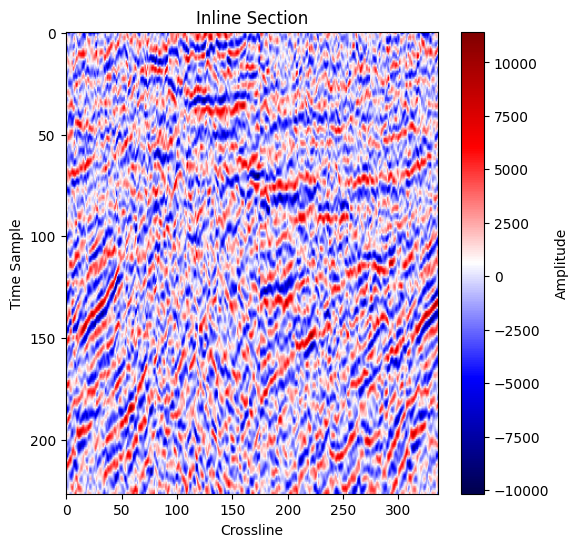

In [43]:
inline_id = cube.shape[0] // 2

plt.figure(figsize=(6,6))

plt.imshow(cube[inline_id,:,:].T,
           cmap="seismic",
           aspect="auto")

plt.title("Inline Section")
plt.xlabel("Crossline")
plt.ylabel("Time Sample")

plt.colorbar(label="Amplitude")

plt.show()

In [44]:
slice_inline = grid.slice(normal='x', origin=(ni//2,0,0))
slice_crossline = grid.slice(normal='y', origin=(0,nx//2,0))
slice_time = grid.slice(normal='z', origin=(0,0,nt//2))

/tmp/ipykernel_149194/3233008531.py:7: UserWarning: Failed to use notebook backend: 

Please install `nest_asyncio2` to automagically launch the trame server without await. Or, to avoid `nest_asyncio2` run:

from pyvista.trame.jupyter import launch_server
await launch_server().ready

Falling back to a static output.
  plotter.show()


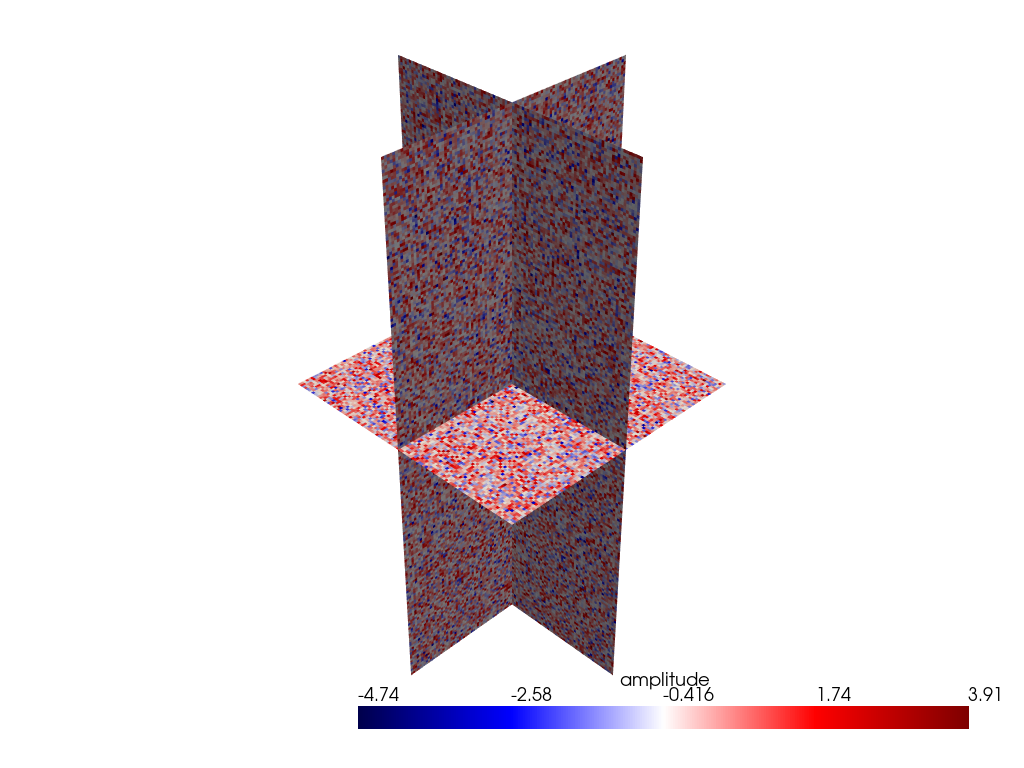

In [45]:
plotter = pv.Plotter()

plotter.add_mesh(slice_inline, cmap="seismic")
plotter.add_mesh(slice_crossline, cmap="seismic")
plotter.add_mesh(slice_time, cmap="seismic")

plotter.show()